In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

f:\langchain+graph\campusz\graph\langgraph\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
def chat_node(state: ChatState):

    messages = state['messages']
    response = model.invoke(messages)
    return {
        'messages': [response]
    }

In [4]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

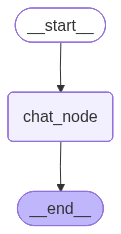

In [5]:
chatbot = graph.compile(checkpointer=checkpointer)
chatbot

In [6]:
initial_state = {
    'messages': [HumanMessage(content="what is capital of india")]
}

# chatbot.invoke(initial_state)['messages'][-1].content

In [ ]:
thread_id = '1'
 
while True:

    user_message = input("Type here: ")
    print("user: ", user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    config = {'configurable':{'thread_id': thread_id}}

    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)
    
    print("AI: ", response['messages'][-1].content)

user:  Hello
AI:  Hello! How can I help you today?
user:  im het,
AI:  Okay, thanks for sharing that with me.

How can I help you today? Is there something specific you'd like to discuss or know about?
user:  whats my name
AI:  I don't know your name! As an AI, I don't have access to personal information about you unless you choose to tell me.

Would you like to tell me your name, or is there something else you'd like to ask?
user:  hello my name is het 23 old 
AI:  Hello Het, it's nice to meet you! And thanks for letting me know your age.

How can I help you today, Het? What's on your mind?
user:  tell me about myself
AI:  Okay, Het. Based on what you've told me, here's what I know about you:

*   **Your name is Het.**
*   **You are 23 years old.**

That's all the personal information I have. As an AI, I don't have access to your personal history, experiences, personality, or anything else about your life beyond what you choose to share with me in our conversation.

If you'd like to t

In [8]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='63240d52-4dde-4a0c-b935-5cc359be2ae5'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019c8ab1-ddfe-7031-9a24-163864a93470-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 35, 'total_tokens': 37, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 26}}), HumanMessage(content='im het,', additional_kwargs={}, response_metadata={}, id='4b2af745-7bae-4449-9fb0-71afdd50979b'), AIMessage(content="Okay, thanks for sharing that with me.\n\nHow can I help you today? Is there something specific you'd like to discuss or know about?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_